# Oppgave 3
Definerer simulasjon for alternerende potensialer

In [74]:
#Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random
import math

#Setter opp plotteparametere
plt.rcParams['figure.figsize'] = [12, 8]  # Width, Height in inches


# Sannsynlighetstettheter for steg til høyre, venstre og ingen steg.
def p_plus(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped+h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped+h))))

def p_null(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped))) + np.exp(-beta*(V(x_clipped+h)-V(x_clipped))))

def p_minus(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped+h)-V(x_clipped-h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped-h))))

beta = 1000                     # Beta parameteren for at potensialet skal dominere sannsynlighetstettetene
delta_t = 1                     # Tidssteg lengde
h = 1                           # Steg lengde
timeCycle = 75              # Antall tidssykluser når en tidssyklus er ferdig når man har byttet potensial en gang
number_of_particles = 3         # Antall partikler
N_x = 100                       # Lengde på perioden til potensialet
T_p = 200                       # Antall tidssteg i en tidssyklus
k_even = 1                      # Konstant for det konstante potensialet
k_odd = 1                       # Konstant for sagtann potensialet
alpha = 0.1                     # Parameter for sagtann potensialet
bin_size = int(2* np.cbrt(N_x)) # Antall bins i histogrammet

# Konstant potensial
def V_even(x, alpha):
    return k_even

# Sagtann potensial
def V_odd(x, alpha):
    x_mod = x % N_x
    if x_mod < alpha * N_x:
        return k_odd * x_mod / (alpha*N_x)
    else:
        return k_odd * (N_x - x_mod) / ((1 - alpha)*N_x)


# Funksjon for random walk simulasjon i alternerende potensial
def sim2(T_p, N_x, x_start, alpha):
    x = np.zeros((2*timeCycle, number_of_particles))
    x[0] = x_start
    X = x.copy() # Array med posisjonene til partiklene uten at de looper rundt
    X_cycle = np.zeros((timeCycle, number_of_particles)) # Array for å lagre posisjonene til partiklene for hver tidssyklus
    J = np.zeros(2*timeCycle*T_p) # Array for å lagre bevegelsesstrømmen for hvert tidssteg for hver tidssyklus
    for k in range(0, 2*timeCycle, delta_t):
        if k % 2 == 0:  # For å kjøre igjennom begge potensialene hver tidssyklus
            V = lambda x: V_even(x, alpha)
        else:
            V = lambda x: V_odd(x, alpha)

        for i in range(0, T_p, delta_t):
            previous_X = np.zeros(number_of_particles)
            for j in range(number_of_particles):
                a = random.uniform(0, 1) # Trekker fra std norm fordeling og flytter partikkel tilsvarende
                previous_X[j] = X[k][j]

                if a <= p_minus(x[k][j], V):
                    x[k][j] -= h
                elif (1 - p_plus(x[k][j], V)) < a:
                    x[k][j] += h

                if (1 - p_plus(X[k][j], V)) < a:
                    X[k][j] += h 
                elif a <= p_minus(X[k][j], V):
                    X[k][j] -= h 

                if x[k][j]  == -N_x -h:
                    x[k][j] = N_x
                elif x[k][j] == N_x + h:
                    x[k][j] = -N_x

                if j == number_of_particles - 1:
                    J[T_p*k+i] = np.mean(X[k] - previous_X)

                if i == T_p - delta_t and k != 2*timeCycle - delta_t:
                    x[k+1][j] = x[k][j]
                    X[k+1][j] = X[k][j]
                    
    #Finner gjennomsnittlig bevegelsesstrøm for hver tidssyklus                    
    J_avg = np.zeros(timeCycle)
    for i in range(timeCycle):
        J_avg[i] = np.mean(J[i*2*T_p:(i+1)*2*T_p])

    for i in range(timeCycle):
        for j in range(number_of_particles):
            X_cycle[i, j] = X[2*i+1][j]

    return x, X, X_cycle, J, J_avg


# a)

Her kan man se at partiklene beveger seg i en retning, siden de sprer seg i det konstante potensialet
og blir dyttet til neste sagtann brønn i sagtann potensialet(hvis de har kommet seg nok til høyre)


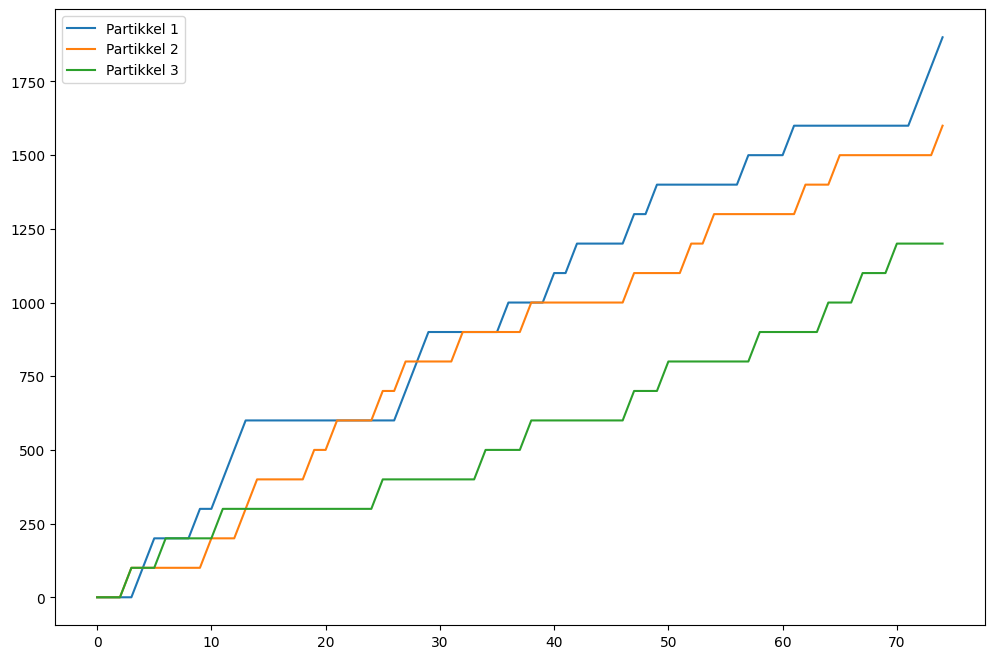

In [14]:
timeCycle = 75          # 75 tidssykluser med 2 potensialer i hver syklus
number_of_particles = 3 # Antall partikler
alpha = 0.1             # Parameter for sagtann potensialet
T_p = 200               # Antall tidssteg per tidssyklus
N_x = 100               # Lengden av perioden til potensialet
h = 1                   # Lengden av stegene
delta_t = 1             # Lengden av tidsstegene
beta = 1000             # Beta parameteren for at potensialet skal dominere sannsynlighetstettetene

x_start =  np.zeros(number_of_particles) # Array med alle partikklene i posisjon x=0, iterer gjennom partikler og tidssteg

print("Her kan man se at partiklene beveger seg i en retning, siden de sprer seg i det konstante potensialet\nog blir dyttet til neste sagtann brønn i sagtann potensialet(hvis de har kommet seg nok til høyre)")
# Kjører simuleringen og plotter bevegelsesstrømmen
x1, X1, X_cycle1, J1, J_avg1 = sim2(T_p, N_x, x_start, alpha)
for i in range(number_of_particles):
    plt.plot(X_cycle1[:, i], label=f"Partikkel {i+1}")
plt.legend()
plt.show()

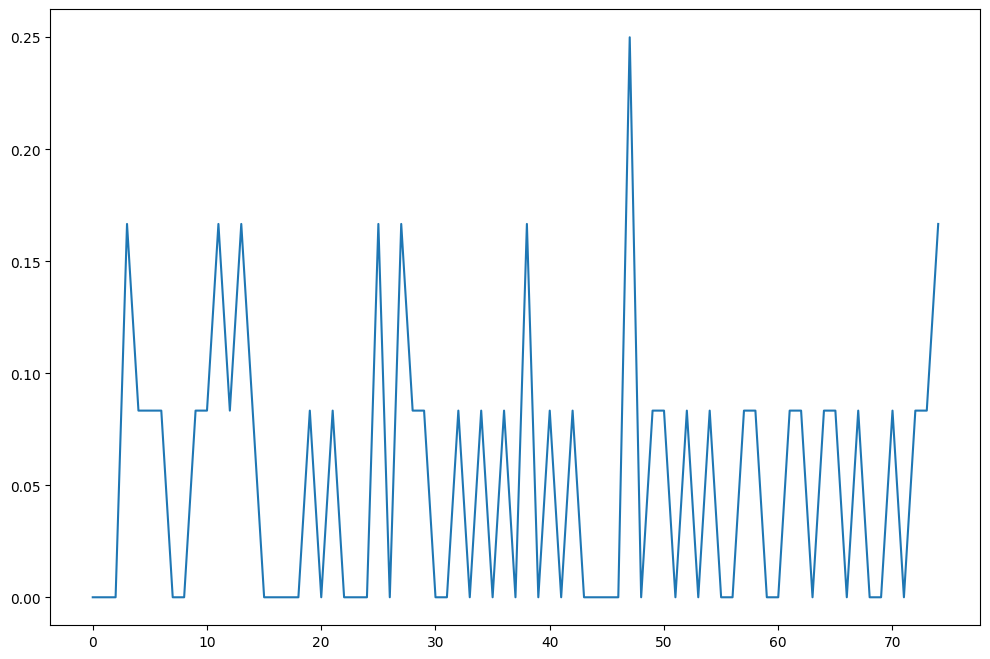

In [15]:
plt.plot(J_avg1)
plt.show()

# b)

In [17]:
alpha = 0.8                     # Endrer alpha for å se om det påvirker bevegelsesstrømmen
T_p = 500                       # Øker antall tidssteg per tidssyklus for å se om det påvirker bevegelsesstrømmen
N_x = 20                        # Enderer lengden på potensialperioden for at antall partikler ikke skal bli for stort
number_of_particles = 2*N_x    # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 10                  # 10 tidssykluser med 2 potensialperioder i hver
h = 20/100                      # Endrer steglengden for at det skal være likt som om N_x var 100

#Initialiserer 6 partikler i hver posisjonen(heltall) mellom -N_x og N_x
integers = range(-N_x, N_x)
x_start = np.array([i for i in integers for _ in range(1)])

x2, X2, X_cycle2, J2, J_avg2 = sim2(T_p, N_x, x_start, alpha)    # Kjører simulasjonen med de nye startposisjonene
alpha = 0.1                                                      # Setter alpha tilbake til 0.1
x3, X3, X_cycle3, J3, J_avg3 = sim2(T_p, N_x, x_start, alpha)    # Kjører simulasjonen med de nye startposisjonene og med alpha = 0.1

Her ser man at partiklene sprer seg overalt i det konstante potensialet og så samler seg i bunnen av sagtann potensialet.
Det er en gjennomsnittlig negativ strøm igjennom hele simuleringen siden alpha = 0.8.


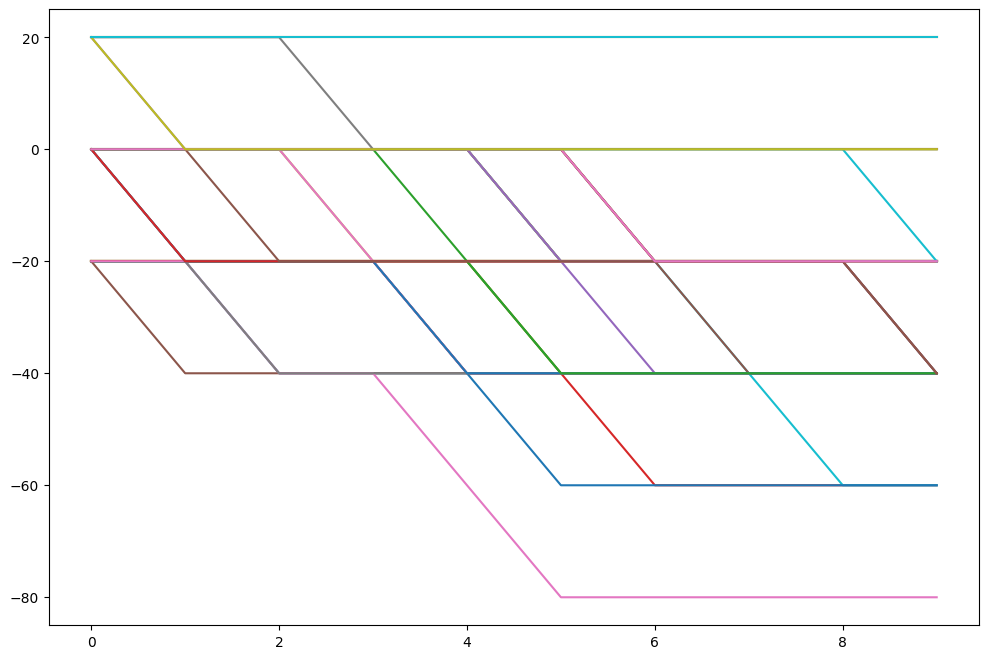

Som man kan se på plottet er det en liten negativ strøm rett etter potensialet har byttet til sagtann potensialet og så er det 0 resten.
Det er dette som gjør at J_avg ikke er null og for det meste negativ.


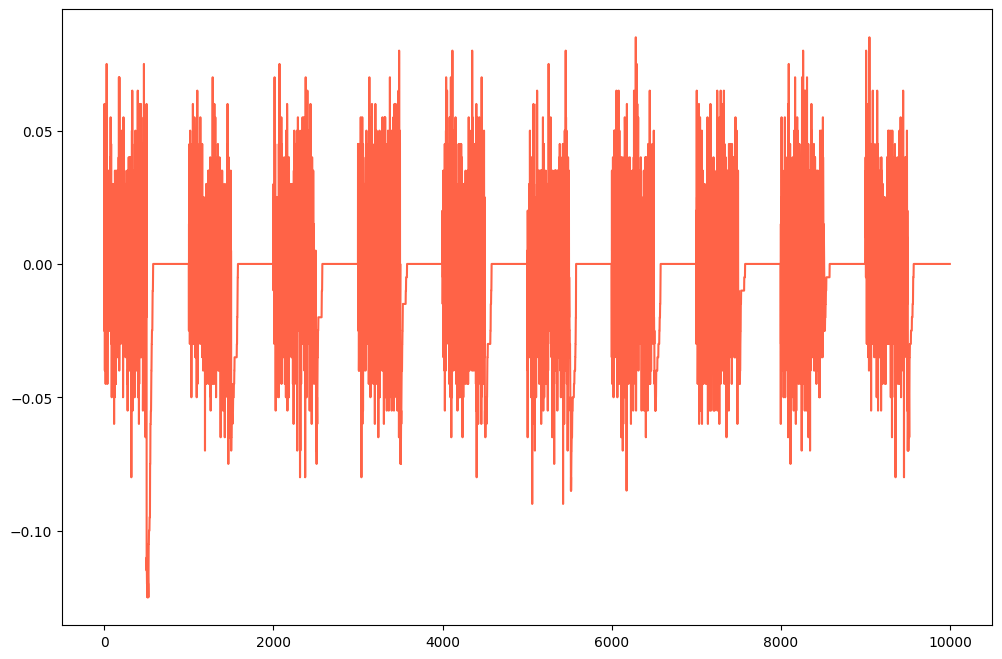

Gjennomsnittlig bevegelsesstrøm for hver tidssyklus:
-5.00e-03, -3.50e-03, -2.00e-03, -1.50e-03, -3.00e-03, -5.00e-03, -3.00e-03, -1.00e-03, -5.00e-04, -2.50e-03, 



In [18]:
print("Her ser man at partiklene sprer seg overalt i det konstante potensialet og så samler seg i bunnen av sagtann potensialet.\nDet er en gjennomsnittlig negativ strøm igjennom hele simuleringen siden alpha = 0.8.")
#Plotter posisjonene til partiklene i slutten av hver tidssyklus
for i in range(number_of_particles):
    plt.plot(X_cycle2[:, i], label=f"Partikkel {i+1}")
plt.show()

print("Som man kan se på plottet er det en liten negativ strøm rett etter potensialet har byttet til sagtann potensialet og så er det 0 resten.\nDet er dette som gjør at J_avg ikke er null og for det meste negativ.")
#Plotter bevegelsesstrømmen for hver tidssyklus
plt.plot(J2, color='tomato')
plt.show()

print("Gjennomsnittlig bevegelsesstrøm for hver tidssyklus:")
for i in range(len(J_avg2)):
    print(f"{J_avg2[i]:.2e}", end=", ")
print("\n")

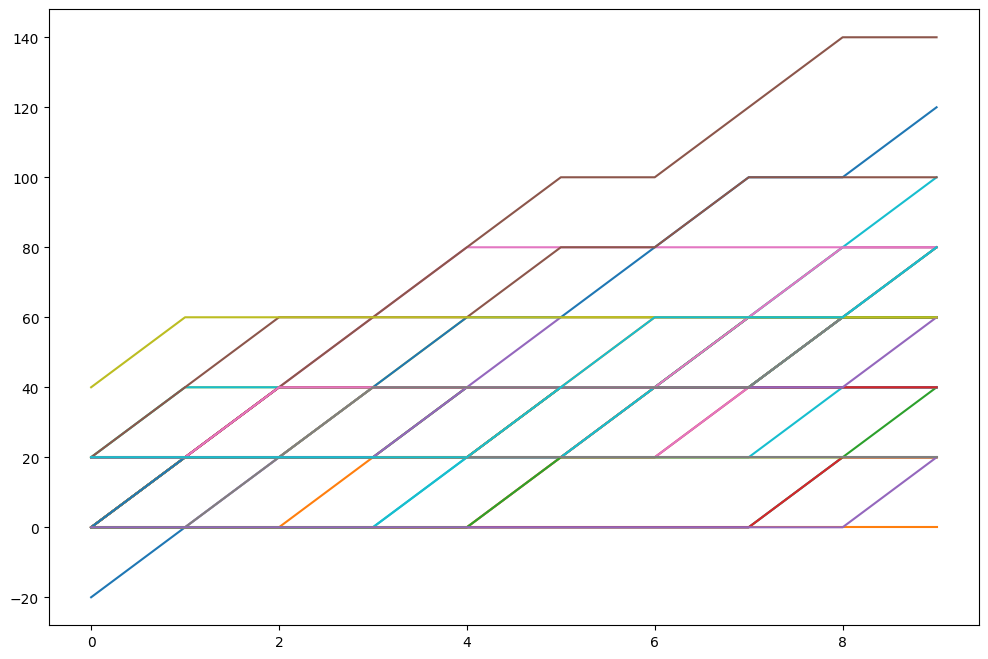

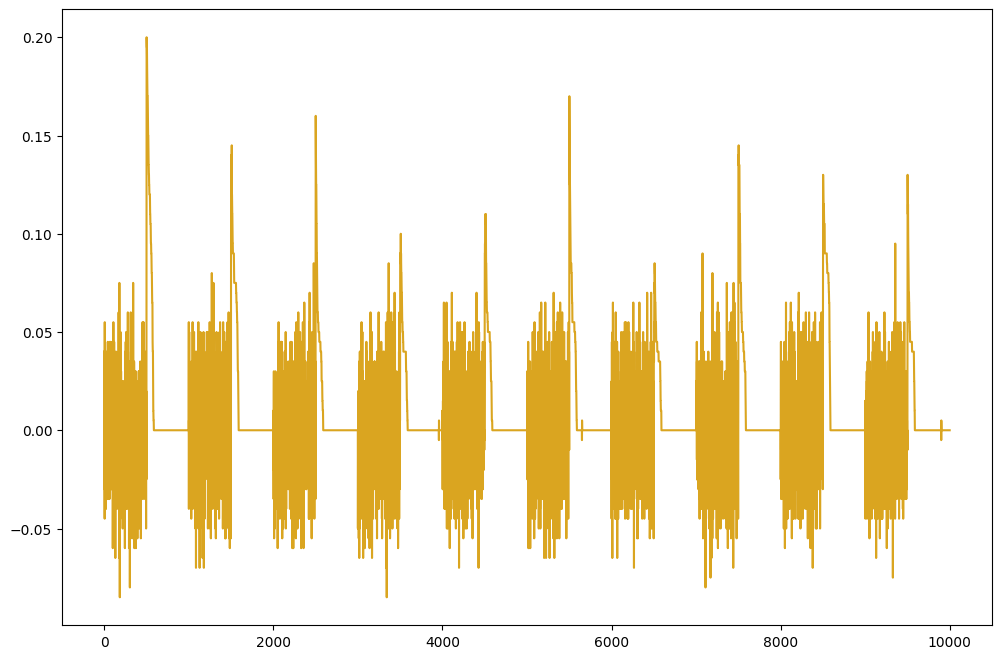

8.50e-03, 7.50e-03, 5.00e-03, 4.00e-03, 5.00e-03, 5.50e-03, 4.00e-03, 5.00e-03, 8.00e-03, 4.50e-03, 

In [19]:
#Alpha = 0.1

for i in range(number_of_particles):
    plt.plot(X_cycle3[:, i], label=f"Partikkel {i+1}")
plt.show()

plt.plot(J3, color='goldenrod')
plt.show()

for i in range(len(J_avg3)):
    print(f"{J_avg3[i]:.2e}", end=", ")

# c)

In [40]:
alpha = 0.8                    # Endrer alpha for å se om det påvirker bevegelsesstrømmen
N_x = 10                        # Enderer lengden på potensialperioden for at antall partikler ikke skal bli for stort
number_of_particles = 4*N_x     # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # 10 tidssykluser med 2 potensialperioder i hver
h = 10/100                      # Endrer steglengden for at det skal være likt som om N_x var 100

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))])

T_p = 1
T_p_array = []

X4_sum = []
J_avg_sum = []
for r in range(50):
    T_p_array.append(T_p)
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha)
    X4_sum.append(X_cycle4[0])
    J_avg_sum.append(J_avg4[0])
    T_p += 10

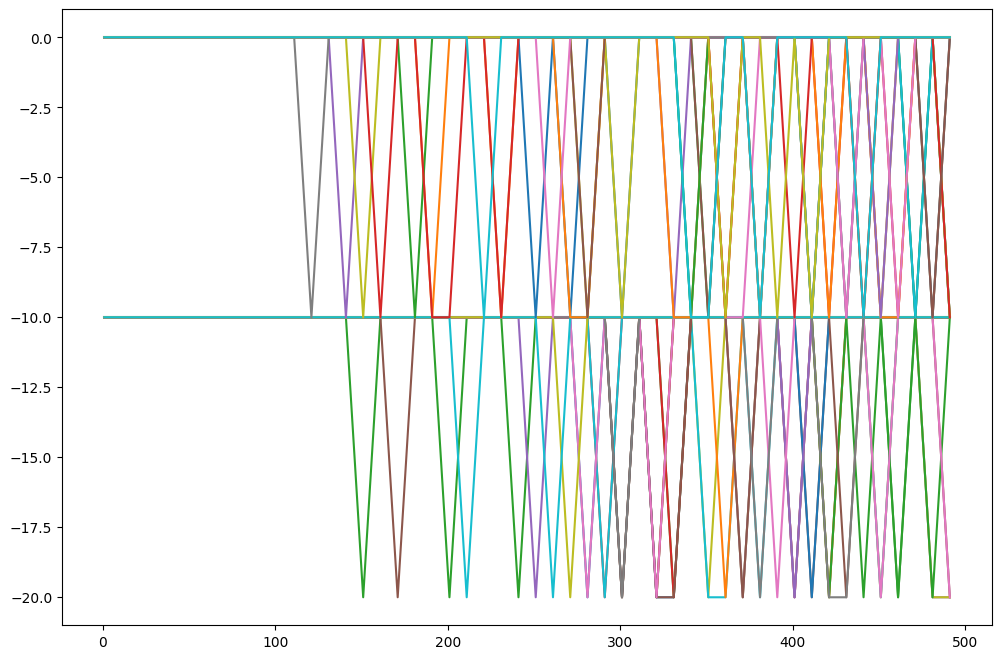

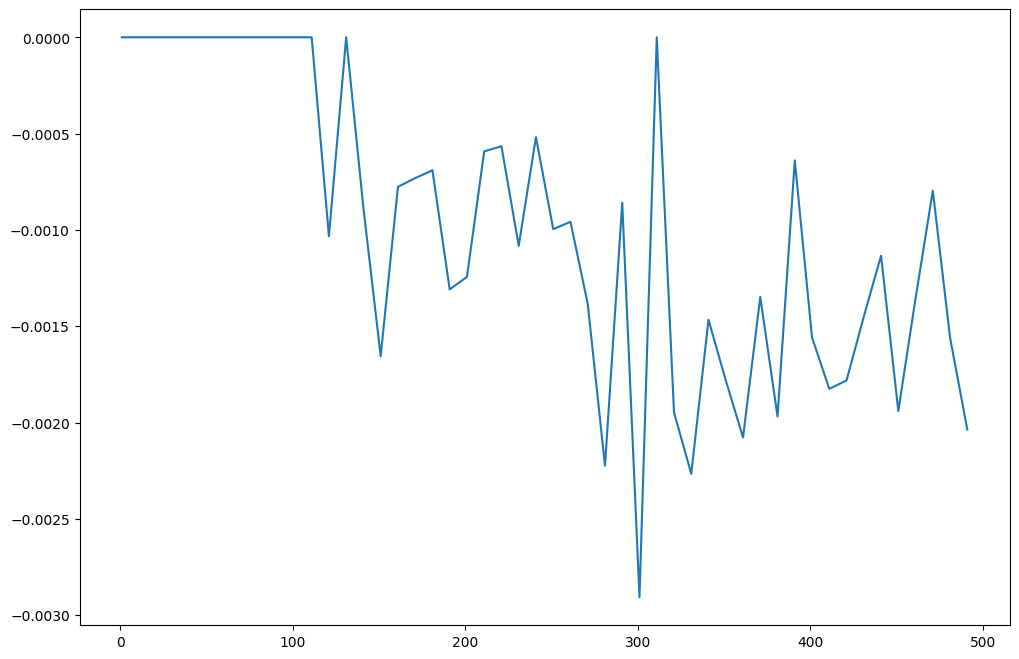

In [41]:
plt.plot(T_p_array, X4_sum)
plt.show()

plt.plot(T_p_array, J_avg_sum)
plt.show()

# d)

In [82]:
T_p = 500                       # Endrer alpha for å se om det påvirker bevegelsesstrømmen
N_x = 10                        # Enderer lengden på potensialperioden for at antall partikler ikke skal bli for stort
number_of_particles = 4*N_x     # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # 10 tidssykluser med 2 potensialperioder i hver
h = 10/100                      # Endrer steglengden for at det skal være likt som om N_x var 100

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))])

alpha = 0
alpha_array = []

X4_sum = []
J_avg_sum = []
for r in range(50):
    alpha_array.append(alpha)
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha)
    X4_sum.append(X_cycle4[0])
    J_avg_sum.append(J_avg4[0])
    alpha += 0.02

C:\Users\Trond\AppData\Local\Temp\ipykernel_13224\2518503808.py:15: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped+h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped+h))))
C:\Users\Trond\AppData\Local\Temp\ipykernel_13224\2518503808.py:23: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped+h)-V(x_clipped-h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped-h))))


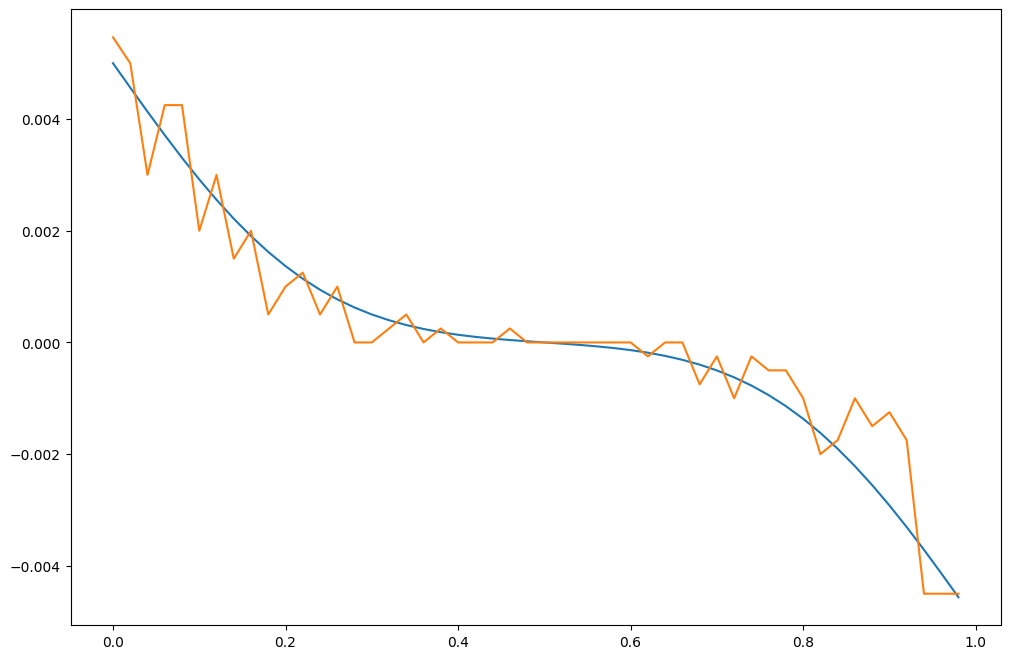

In [83]:


D = 1/3
T_p = 500
N_x_analytic = 100
alphaArray = np.arange(0, 1, 1/50)

def J_avg(alpha, T_p, N_x):
    J = (N_x/(4*T_p))*(math.erfc((alpha*N_x/2)*np.sqrt(3/T_p)) - math.erfc(((1-alpha)*N_x/2)*np.sqrt(3/T_p)))
    return J

J_analytic = []
for alphaValues in alphaArray:
    J_analytic.append(J_avg(alphaValues, T_p, N_x_analytic))

plt.plot(alphaArray, N_x/N_x_analytic * np.array(J_analytic))
plt.plot(alpha_array, J_avg_sum)
plt.show()